In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive'):
    if 'finance_economics_dataset.xlsx' in files:
        print("FOUND:")
        print(os.path.join(root, 'finance_economics_dataset.xlsx'))


FOUND:
/content/drive/MyDrive/Colab Notebooks/finance_economics_dataset.xlsx


In [ ]:
# 2. Import pandas
import pandas as pd

# 3. Path to your Excel file
file_path = '/content/drive/MyDrive/Colab Notebooks/finance_economics_dataset.xlsx'

# 4. Load the Excel file
df = pd.read_excel(file_path)

# 5. Display the first 5 rows
df.head()


,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
0,2000-01-01,Dow Jones,2128.75,2138.48,2143.70,2100.55,2670411,-0.37,6.06,6.10,...,1.04,119.87,47.20,1052.34,390.23,2229,2.12,3,76.64,4589
1,2000-01-02,S&P 500,2046.82,2036.18,2082.83,2009.53,690220415,3.19,4.95,6.62,...,1.00,98.22,52.84,1957.73,346.23,4156,1.40,21,5.67,10101
2,2000-01-03,Dow Jones,1987.92,1985.26,2022.28,1978.37,315284661,5.54,9.13,2.60,...,0.83,80.13,78.80,2339.49,439.46,340,0.79,48,39.43,13665
3,2000-01-04,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,0.95,149.15,28.18,1308.54,213.07,8456,4.22,16,12.83,5192
4,2000-01-05,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,1.43,113.71,92.20,2210.08,405.49,1596,2.21,34,86.37,10688


In [ ]:
print("Initial Columns:", df.columns.tolist())
print("Initial Shape:", df.shape)



Initial Columns: ['Date', 'Stock Index', 'Open Price', 'Close Price', 'Daily High', 'Daily Low', 'Trading Volume', 'GDP Growth (%)', 'Inflation Rate (%)', 'Unemployment Rate (%)', 'Interest Rate (%)', 'Consumer Confidence Index', 'Government Debt (Billion USD)', 'Corporate Profits (Billion USD)', 'Forex USD/EUR', 'Forex USD/JPY', 'Crude Oil Price (USD per Barrel)', 'Gold Price (USD per Ounce)', 'Real Estate Index', 'Retail Sales (Billion USD)', 'Bankruptcy Rate (%)', 'Mergers & Acquisitions Deals', 'Venture Capital Funding (Billion USD)', 'Consumer Spending (Billion USD)']
Initial Shape: (3000, 24)


In [ ]:
print(df.describe())
print(df.head())
print(df.info())

                                Date   Open Price  Close Price   Daily High  \
count                           3000  3000.000000  3000.000000  3000.000000   
mean   2004-02-08 11:59:59.999999872  2982.094607  2981.249173  3018.887777   
min              2000-01-01 00:00:00  1000.050000   954.520000  1012.130000   
25%              2002-01-19 18:00:00  1994.982500  1997.425000  2035.952500   
50%              2004-02-08 12:00:00  2970.780000  2977.180000  3006.520000   
75%              2006-02-27 06:00:00  3974.690000  3982.082500  4015.217500   
max              2008-03-18 00:00:00  4998.230000  5034.130000  5076.190000   
std                              NaN  1151.862689  1151.783841  1151.683485   

        Daily Low  Trading Volume  GDP Growth (%)  Inflation Rate (%)  \
count  3000.00000    3.000000e+03     3000.000000         3000.000000   
mean   2944.32975    5.033864e+08        2.608903            5.096830   
min     917.17000    1.636024e+06       -5.000000            0.010000

In [ ]:
df = df.drop_duplicates()

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

In [ ]:
non_numeric_cols = df.select_dtypes(include=["object"]).columns
numeric_cols = df[df.columns.difference(non_numeric_cols)]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# Handle categorical 'Stock Index' if present (One-Hot Encoding)
if "Stock Index" in df.columns:
    df = pd.get_dummies(df, columns=["Stock Index"], drop_first=True)

In [ ]:
# Create Target: 1 if tomorrow's Close Price > today's Close Price, else 0
df["Target"] = (df["Close Price"].shift(-1) > df["Close Price"]).astype(int)

# Create Daily Return for feature engineering
df["Daily_Return"] = df["Close Price"].pct_change()


> df["Close Price"].shift(-1): Takes the Close Price column and slides all values up by 1 row. This effectively aligns tomorrow's price with today's row.
> df["Close Price"]: Compares tomorrow's price against today's price. It evaluates to True if the stock went UP tomorrow, and False if it went DOWN or stayed FLAT..astype(int): Converts True to 1 and False to 0.

This creates your classification label ($y$).df["Close Price"].pct_change(): Calculates the daily percentage change in price relative to the previous day: $\frac{\text{Price}_{\text{today}} - \text{Price}_{\text{yesterday}}}{\text{Price}_{\text{yesterday}}}$.

Intuitive Explanation:Imagine you are looking at today's newspaper. You want your machine learning model to guess tomorrow's headline: "Stock Market Rose Today" (1) or "Stock Market Fell Today" (0).To teach the model, you go back through historical data. For every single day in history, you look at what happened on the very next day and write down a 1 or 0 as the "answer key." That answer key is your Target.Meanwhile, Daily_Return tells the model how much momentum the stock had today compared to yesterday so it can learn patterns (e.g., "When stock returns drop two days in a row, does it usually bounce back on day three?").

In [ ]:
df = df.ffill().bfill()

In [ ]:
# Drop incomplete rows created by rolling windows and shifting target
df = df.dropna().reset_index(drop=True)

In [ ]:
# Select numeric features for X while explicitly excluding targets
X = df.select_dtypes(include=["number"]).drop(
    columns=["Target", "Tomorrow_Return"], errors="ignore"
)

y = df["Target"]

In [ ]:


# ==========================================
# 6. CHRONOLOGICAL TRAIN/TEST SPLIT (80/20)
# ==========================================
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ==========================================
# 7. FEATURE SCALING
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 8. ANTI-OVERFITTING MODEL TRAINING
# ==========================================
# Logistic Regression with L2 Regularization (C=0.1 prevents overfitting)
lr_model = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest with depth limits and minimum leaf samples to reduce variance
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
    }


results = {
    "Logistic Regression": evaluate_model(y_test, y_pred_lr, y_prob_lr),
    "Random Forest": evaluate_model(y_test, y_pred_rf, y_prob_rf),
}

In [ ]:
comparison_df = pd.DataFrame(results).T
print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(comparison_df.round(4))

print("\n=== CONFUSION MATRICES ===")
print("Logistic Regression Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nRandom Forest Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


=== MODEL PERFORMANCE COMPARISON ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.775     0.7886  0.7655    0.7769   0.8344
Random Forest           0.765     0.7730  0.7655    0.7692   0.8371

=== CONFUSION MATRICES ===
Logistic Regression Matrix:
[[230  63]
 [ 72 235]]

Random Forest Matrix:
[[224  69]
 [ 72 235]]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_curve

# Set style for analytics plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10})


comparison_df = pd.DataFrame(results).T
print("\n" + "=" * 50)
print("       MODEL PERFORMANCE COMPARISON TABLE       ")
print("=" * 50)
print(comparison_df.round(4))

print("\n" + "=" * 50)
print("     LOGISTIC REGRESSION CLASSIFICATION REPORT  ")
print("=" * 50)
print(classification_report(y_test, y_pred_lr))

print("\n" + "=" * 50)
print("       RANDOM FOREST CLASSIFICATION REPORT      ")
print("=" * 50)
print(classification_report(y_test, y_pred_rf))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)





       MODEL PERFORMANCE COMPARISON TABLE       
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.775     0.7886  0.7655    0.7769   0.8344
Random Forest           0.765     0.7730  0.7655    0.7692   0.8371

     LOGISTIC REGRESSION CLASSIFICATION REPORT  
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       293
           1       0.79      0.77      0.78       307

    accuracy                           0.78       600
   macro avg       0.78      0.78      0.77       600
weighted avg       0.78      0.78      0.78       600


       RANDOM FOREST CLASSIFICATION REPORT      
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       293
           1       0.77      0.77      0.77       307

    accuracy                           0.77       600
   macro avg       0.76      0.76      0.76       600
weighted avg       0.77      0.77      0.77    

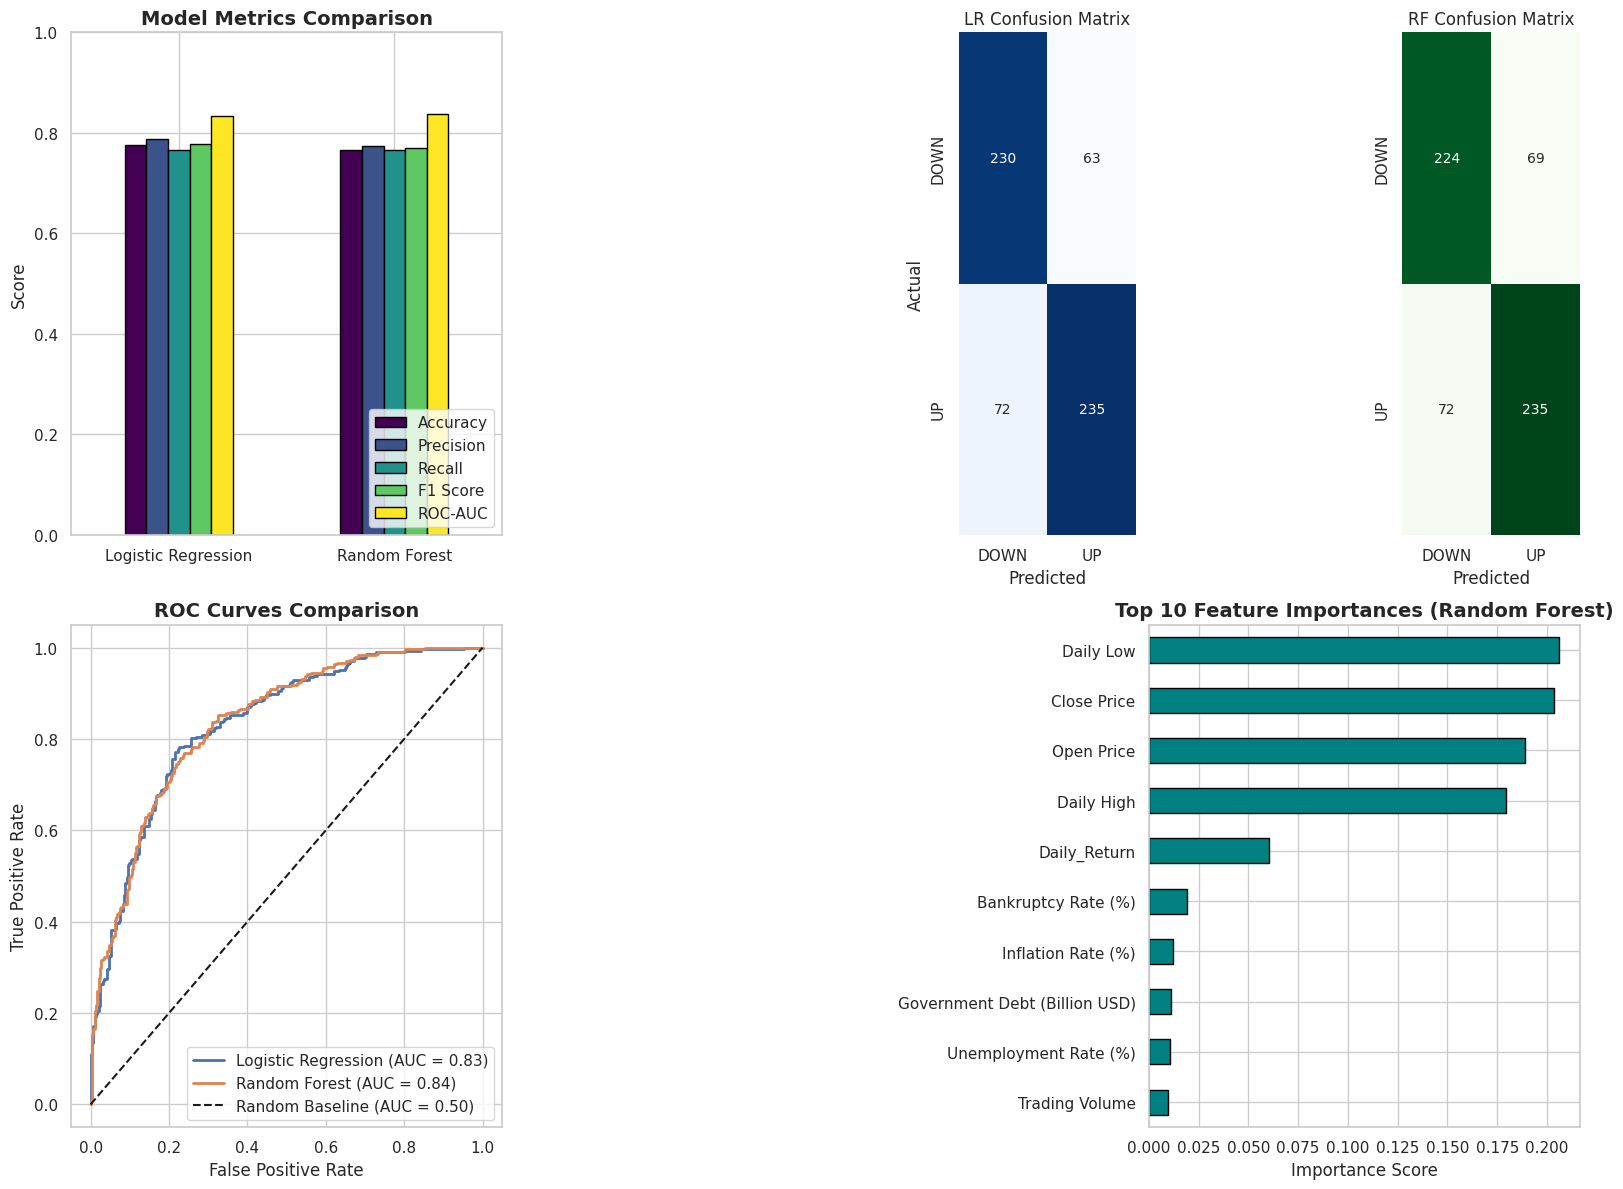

In [ ]:
# ==========================================
# 10. ANALYTICS VISUALIZATIONS (GRAPHS)
# ==========================================
fig = plt.figure(figsize=(16, 12))

# Graph 1: Performance Metrics Comparison Bar Chart
ax1 = plt.subplot(2, 2, 1)
comparison_df.plot(kind="bar", ax=ax1, colormap="viridis", edgecolor="black")
plt.title("Model Metrics Comparison", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

# Graph 2: Confusion Matrices (Heatmaps)
ax_cm1 = fig.add_subplot(2, 4, 3)
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["DOWN", "UP"],
    yticklabels=["DOWN", "UP"],
    ax=ax_cm1,
)
ax_cm1.set_title("LR Confusion Matrix")
ax_cm1.set_xlabel("Predicted")
ax_cm1.set_ylabel("Actual")

ax_cm2 = fig.add_subplot(2, 4, 4)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["DOWN", "UP"],
    yticklabels=["DOWN", "UP"],
    ax=ax_cm2,
)
ax_cm2.set_title("RF Confusion Matrix")
ax_cm2.set_xlabel("Predicted")

# Graph 3: ROC Curves
ax3 = plt.subplot(2, 2, 3)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {results['Logistic Regression']['ROC-AUC']:.2f})",
    linewidth=2,
)
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {results['Random Forest']['ROC-AUC']:.2f})",
    linewidth=2,
)
plt.plot([0, 1], [0, 1], "k--", label="Random Baseline (AUC = 0.50)")
plt.title("ROC Curves Comparison", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# Graph 4: Top 10 Feature Importances (Random Forest)
ax4 = plt.subplot(2, 2, 4)
# Corrected: Use X.columns for feature names as X was used to train the model
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_10 = importances.nlargest(10).sort_values(ascending=True)

top_10.plot(kind="barh", color="teal", ax=ax4, edgecolor="black")
plt.title(
    "Top 10 Feature Importances (Random Forest)", fontsize=14, fontweight="bold"
)
plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()